In [1]:
from google.colab import files
uploaded = files.upload()

Saving ecommerce_customer_data_custom_ratios.csv to ecommerce_customer_data_custom_ratios.csv


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv('ecommerce_customer_data_custom_ratios.csv')


df['Purchase Date'] = pd.to_datetime(df['Purchase Date'])
df['Month'] = df['Purchase Date'].dt.month
df['Year'] = df['Purchase Date'].dt.year

print(" Data loaded!")
print(f"Total rows: {len(df)}")
print(f"Columns: {list(df.columns)}")

 Data loaded!
Total rows: 250000
Columns: ['Customer ID', 'Purchase Date', 'Product Category', 'Product Price', 'Quantity', 'Total Purchase Amount', 'Payment Method', 'Customer Age', 'Returns', 'Customer Name', 'Age', 'Gender', 'Churn', 'Month', 'Year']


In [3]:
total_revenue = df['Total Purchase Amount'].sum()
total_customers = df['Customer ID'].nunique()
avg_order = df['Total Purchase Amount'].mean()
churn_rate = (df.groupby('Customer ID')['Churn'].max().mean()) * 100
return_rate = (df['Returns'].sum() / len(df)) * 100

print("========== KEY KPIs ==========")
print(f" Total Revenue:      ${total_revenue:,.2f}")
print(f" Total Customers:    {total_customers}")
print(f" Avg Order Value:    ${avg_order:,.2f}")
print(f"  Churn Rate:         {churn_rate:.2f}%")
print(f"  Return Rate:        {return_rate:.2f}%")

========== KEY KPIs ==========
 Total Revenue:      $681,342,683.00
 Total Customers:    49673
 Avg Order Value:    $2,725.37
  Churn Rate:         20.01%
  Return Rate:        40.31%


In [4]:
# RFM Analysis
snapshot_date = df['Purchase Date'].max()

rfm = df.groupby('Customer ID').agg({
    'Purchase Date': lambda x: (snapshot_date - x.max()).days,
    'Customer ID': 'count',
    'Total Purchase Amount': 'sum'
}).rename(columns={
    'Purchase Date': 'Recency',
    'Customer ID': 'Frequency',
    'Total Purchase Amount': 'Monetary'
})

# Score each customer 1-4
rfm['R_Score'] = pd.qcut(rfm['Recency'], 4, labels=[4,3,2,1])
rfm['F_Score'] = pd.qcut(rfm['Frequency'].rank(method='first'), 4, labels=[1,2,3,4])
rfm['M_Score'] = pd.qcut(rfm['Monetary'], 4, labels=[1,2,3,4])
rfm['RFM_Score'] = rfm['R_Score'].astype(str) + rfm['F_Score'].astype(str) + rfm['M_Score'].astype(str)

# Segments
def segment(row):
    score = int(row['R_Score']) + int(row['F_Score']) + int(row['M_Score'])
    if score >= 10: return ' Champions'
    elif score >= 8: return ' Loyal Customers'
    elif score >= 6: return ' Potential Loyalists'
    elif score >= 4: return ' At Risk'
    else: return ' Lost Customers'

rfm['Segment'] = rfm.apply(segment, axis=1)
print(rfm['Segment'].value_counts())

Segment
Champions              13796
Loyal Customers        11469
Potential Loyalists    11195
At Risk                 8462
Lost Customers          4751
Name: count, dtype: int64


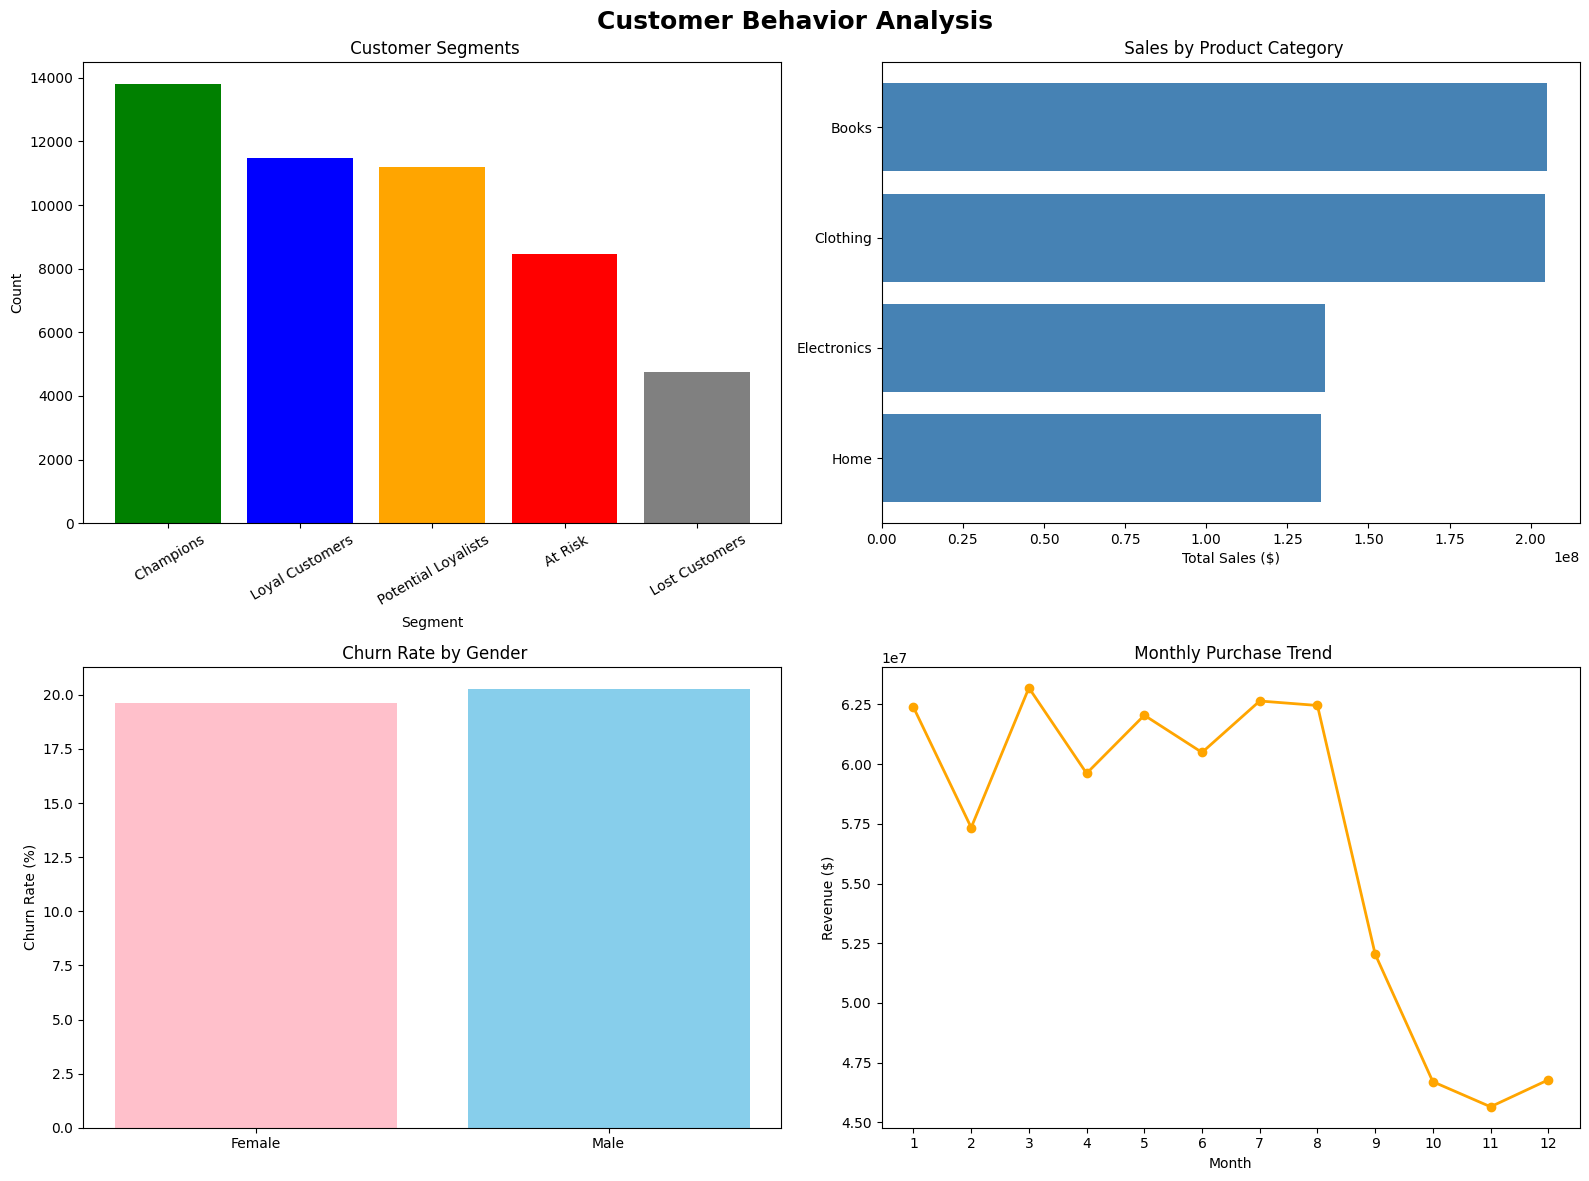

 Charts saved!


In [5]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Customer Behavior Analysis', fontsize=18, fontweight='bold')

# Chart 1: Customer Segments
seg_counts = rfm['Segment'].value_counts()
axes[0,0].bar(seg_counts.index, seg_counts.values, color=['green','blue','orange','red','gray'])
axes[0,0].set_title(' Customer Segments')
axes[0,0].set_xlabel('Segment')
axes[0,0].set_ylabel('Count')
axes[0,0].tick_params(axis='x', rotation=30)

# Chart 2: Sales by Category
cat_sales = df.groupby('Product Category')['Total Purchase Amount'].sum().sort_values()
axes[0,1].barh(cat_sales.index, cat_sales.values, color='steelblue')
axes[0,1].set_title(' Sales by Product Category')
axes[0,1].set_xlabel('Total Sales ($)')

# Chart 3: Churn by Gender
churn_gender = df.groupby('Gender')['Churn'].mean() * 100
axes[1,0].bar(churn_gender.index, churn_gender.values, color=['pink','skyblue'])
axes[1,0].set_title(' Churn Rate by Gender')
axes[1,0].set_ylabel('Churn Rate (%)')

# Chart 4: Monthly Purchase Trend
monthly = df.groupby('Month')['Total Purchase Amount'].sum()
axes[1,1].plot(monthly.index, monthly.values, marker='o', color='orange', linewidth=2)
axes[1,1].set_title(' Monthly Purchase Trend')
axes[1,1].set_xlabel('Month')
axes[1,1].set_ylabel('Revenue ($)')
axes[1,1].set_xticks(range(1,13))

plt.tight_layout()
plt.savefig('customer_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print(" Charts saved!")

1.  Champions segment ko loyalty rewards do — repeat purchase badhega
2.  At Risk customers ko email/discount campaigns bhejo — churn rokne ke liye
3.  Top category pe zyada stock aur marketing invest karo
4. Return rate kam karne ke liye product quality improve karo
5.  Slow months mein seasonal sales chalaao — revenue boost hoga